# Reconhecimento de Dígitos Manuscritos (MNIST) com TensorFlow
Uma rede neural que olha uma imagem de um número escrito à mão (0 a 9) e descobre qual dígito é. Este é o *"Hello World"* da visão computacional.

O conjunto **MNIST** tem 70.000 imagens em tons de cinza, de 28×28 pixels: 60.000 para treinar e 10.000 para testar.

> **Sobre os dados:** o enunciado pede para baixar o `mnist.npz` de `storage.googleapis.com`. Como esse link não é acessível deste ambiente, uso o **arquivo NPZ que foi anexado** — exatamente o mesmo dataset. No Google Colab o download direto também funciona.

Seguimos os 6 passos do enunciado.

## Passo 1 — Importar as bibliotecas

In [7]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL']='3'
os.environ['TF_ENABLE_ONEDNN_OPTS']='0'
import logging, warnings
logging.getLogger('tensorflow').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
tf.keras.utils.set_random_seed(42)
print('TensorFlow', tf.__version__)

TensorFlow 2.20.0


## Passo 2 — Carregar o conjunto de dados e pré-processar
Lemos o `.npz`, que já vem separado em treino e teste.

In [9]:
with np.load('/content/mnist (1).npz') as f:
    x_train, y_train = f['x_train'], f['y_train']
    x_test,  y_test  = f['x_test'],  f['y_test']

print('Imagens de treino:', x_train.shape, '| rotulos:', y_train.shape)
print('Imagens de teste :', x_test.shape,  '| rotulos:', y_test.shape)
print('Cada imagem: 28x28 pixels | valor dos pixels: de', x_train.min(), 'a', x_train.max())

Imagens de treino: (60000, 28, 28) | rotulos: (60000,)
Imagens de teste : (10000, 28, 28) | rotulos: (10000,)
Cada imagem: 28x28 pixels | valor dos pixels: de 0 a 255


Vamos **ver** algumas imagens com seus rótulos verdadeiros:

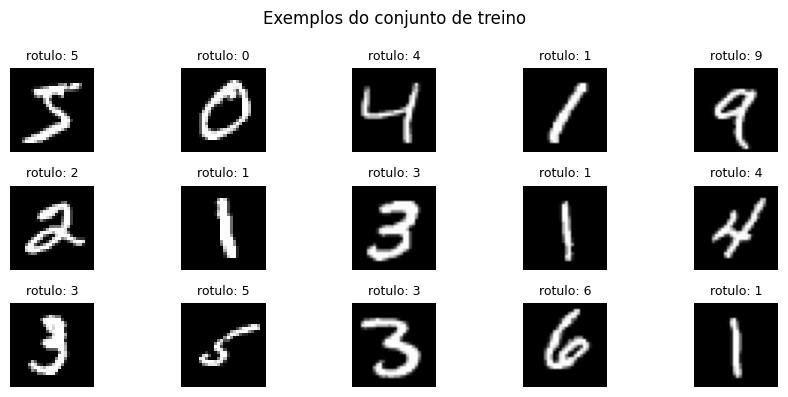

In [10]:
plt.figure(figsize=(9,4))
for i in range(15):
    plt.subplot(3,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f'rotulo: {y_train[i]}', fontsize=9)
    plt.axis('off')
plt.suptitle('Exemplos do conjunto de treino'); plt.tight_layout(); plt.show()

As 10 classes (0–9) estão bem equilibradas — nenhum dígito domina:

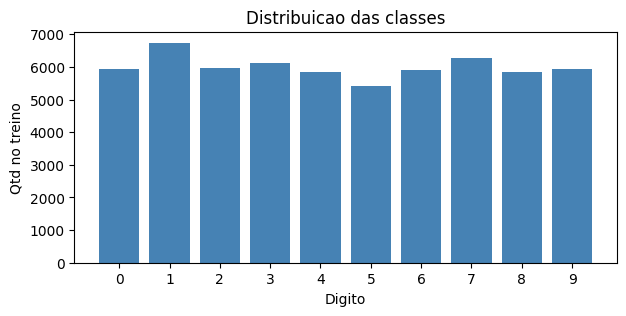

In [11]:
u, c = np.unique(y_train, return_counts=True)
plt.figure(figsize=(7,3))
plt.bar(u, c, color='steelblue')
plt.xticks(u); plt.xlabel('Digito'); plt.ylabel('Qtd no treino')
plt.title('Distribuicao das classes'); plt.show()

**Pré-processamento.** Os pixels vão de 0 a 255. Dividimos por 255 para deixá-los entre **0 e 1** (*normalização*). Isso ajuda a rede a treinar mais rápido e de forma estável. Os rótulos são números inteiros de 0 a 9 — não precisam de transformação.

In [12]:
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0
print('Agora os pixels vao de', x_train.min(), 'a', x_train.max())

Agora os pixels vao de 0.0 a 1.0


## Passo 3 — Construir e compilar o modelo
A arquitetura (uma rede *densa* simples):
- **Flatten**: transforma a imagem 28×28 numa lista de 784 números (a rede recebe um vetor).
- **Dense(128, relu)**: 128 neurônios que aprendem padrões (traços, curvas) das imagens.
- **Dropout(0.2)**: desliga 20% dos neurônios a cada passo no treino, para evitar *overfitting* (decorar).
- **Dense(10)**: 10 saídas, uma pontuação para cada dígito possível (0 a 9).

Na compilação: **otimizador adam**, **perda** apropriada para classificação com rótulos inteiros (`SparseCategoricalCrossentropy`) e acompanhamos a **acurácia** (% de acertos).

In [13]:
model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10)
])
model.compile(optimizer='adam',
              loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## Passo 4 — Treinar o modelo com os dados de treinamento
Treinamos por 10 **épocas** (10 passadas pelos dados). Separamos 10% do treino como **validação** para checar, durante o treino, se a rede está generalizando.

In [14]:
history = model.fit(x_train, y_train,
                    epochs=10, batch_size=128,
                    validation_split=0.1, verbose=2)

Epoch 1/10
422/422 - 4s - 9ms/step - accuracy: 0.8786 - loss: 0.4249 - val_accuracy: 0.9540 - val_loss: 0.1740
Epoch 2/10
422/422 - 2s - 6ms/step - accuracy: 0.9394 - loss: 0.2084 - val_accuracy: 0.9653 - val_loss: 0.1239
Epoch 3/10
422/422 - 2s - 5ms/step - accuracy: 0.9541 - loss: 0.1578 - val_accuracy: 0.9697 - val_loss: 0.1029
Epoch 4/10
422/422 - 2s - 5ms/step - accuracy: 0.9616 - loss: 0.1298 - val_accuracy: 0.9735 - val_loss: 0.0916
Epoch 5/10
422/422 - 2s - 5ms/step - accuracy: 0.9674 - loss: 0.1105 - val_accuracy: 0.9762 - val_loss: 0.0810
Epoch 6/10
422/422 - 2s - 5ms/step - accuracy: 0.9715 - loss: 0.0948 - val_accuracy: 0.9772 - val_loss: 0.0797
Epoch 7/10
422/422 - 3s - 8ms/step - accuracy: 0.9745 - loss: 0.0841 - val_accuracy: 0.9785 - val_loss: 0.0751
Epoch 8/10
422/422 - 2s - 5ms/step - accuracy: 0.9774 - loss: 0.0750 - val_accuracy: 0.9788 - val_loss: 0.0733
Epoch 9/10
422/422 - 2s - 5ms/step - accuracy: 0.9797 - loss: 0.0664 - val_accuracy: 0.9798 - val_loss: 0.0715
E

As curvas de aprendizado. Treino e validação caminhando juntos = aprendizado saudável:

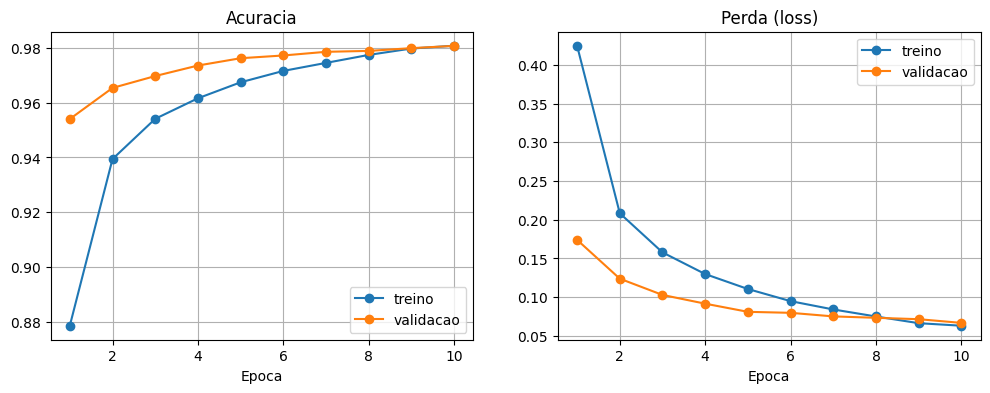

In [15]:
h = history.history
ep = range(1, len(h['loss'])+1)
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(ep, h['accuracy'], 'o-', label='treino')
ax[0].plot(ep, h['val_accuracy'], 'o-', label='validacao')
ax[0].set_title('Acuracia'); ax[0].set_xlabel('Epoca'); ax[0].legend(); ax[0].grid(True)
ax[1].plot(ep, h['loss'], 'o-', label='treino')
ax[1].plot(ep, h['val_loss'], 'o-', label='validacao')
ax[1].set_title('Perda (loss)'); ax[1].set_xlabel('Epoca'); ax[1].legend(); ax[1].grid(True)
plt.show()

## Passo 5 — Avaliar o modelo
Agora medimos a acurácia nos **10.000 dados de teste** — imagens que a rede **nunca viu** no treino.

In [16]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'>>> Acuracia no TESTE: {test_acc*100:.2f}%  (perda: {test_loss:.4f})')

>>> Acuracia no TESTE: 97.66%  (perda: 0.0738)


A **matriz de confusão** mostra onde a rede acerta e erra. A diagonal são os acertos; valores fora dela são confusões (ex.: prever 9 quando era 4).

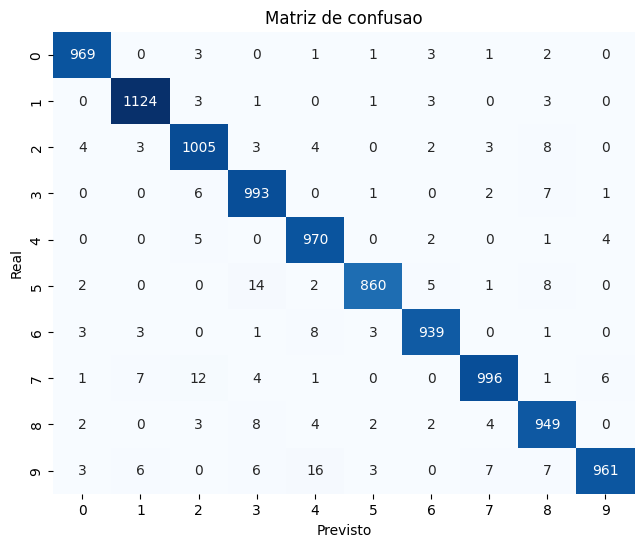

In [17]:
y_pred = model.predict(x_test, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7.5,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Previsto'); plt.ylabel('Real'); plt.title('Matriz de confusao'); plt.show()

In [18]:
print('Acerto por digito (precision/recall/f1):\n')
print(classification_report(y_test, y_pred, digits=3))

Acerto por digito (precision/recall/f1):

              precision    recall  f1-score   support

           0      0.985     0.989     0.987       980
           1      0.983     0.990     0.987      1135
           2      0.969     0.974     0.971      1032
           3      0.964     0.983     0.974      1010
           4      0.964     0.988     0.976       982
           5      0.987     0.964     0.976       892
           6      0.982     0.980     0.981       958
           7      0.982     0.969     0.976      1028
           8      0.961     0.974     0.968       974
           9      0.989     0.952     0.970      1009

    accuracy                          0.977     10000
   macro avg      0.977     0.976     0.976     10000
weighted avg      0.977     0.977     0.977     10000



## Passo 6 — Fazer previsões usando os dados de teste
Para interpretar facilmente, adicionamos uma camada **Softmax** que converte as 10 pontuações em **probabilidades** (somam 100%). A maior probabilidade é o palpite da rede.

In [19]:
probability_model = keras.Sequential([model, layers.Softmax()])
probs = probability_model.predict(x_test, verbose=0)
preds = probs.argmax(axis=1)

# Exemplo de uma previsao
i = 0
print(f'Imagem 0 -> rede preve: {preds[i]}  (confianca {probs[i][preds[i]]*100:.1f}%) | real: {y_test[i]}')

Imagem 0 -> rede preve: 7  (confianca 100.0%) | real: 7


20 previsões em imagens de teste. **Verde** = acertou, **vermelho** = errou (com a confiança em %):

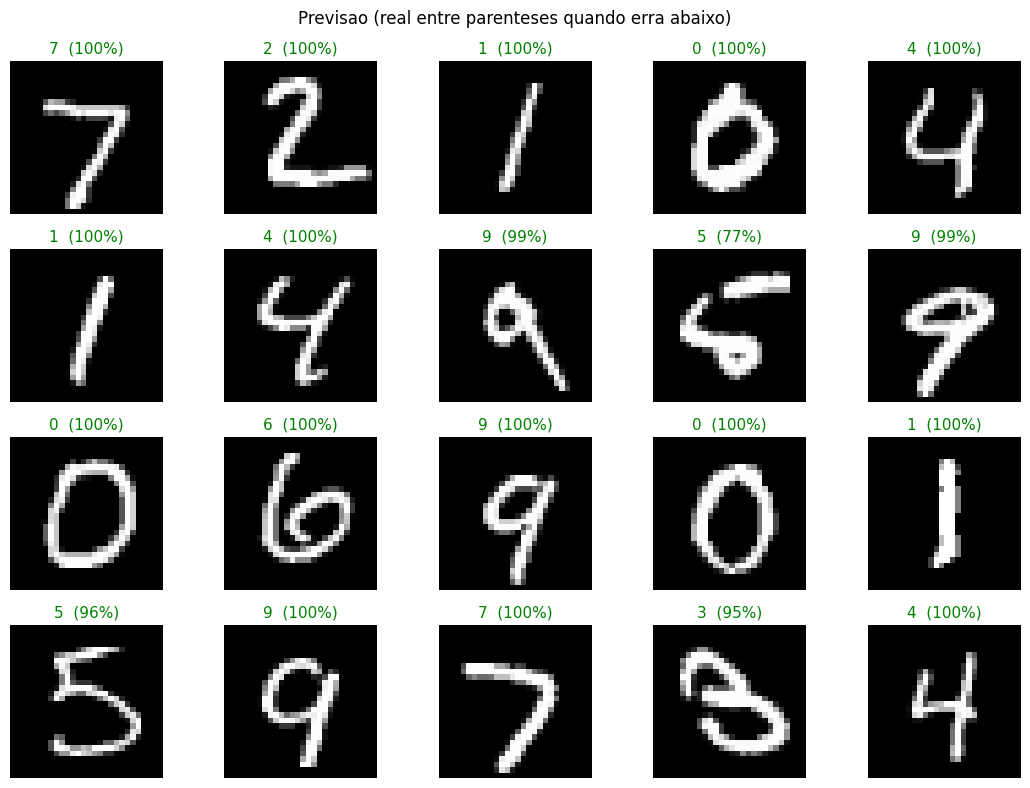

In [20]:
plt.figure(figsize=(11,8))
for i in range(20):
    plt.subplot(4,5,i+1)
    plt.imshow(x_test[i], cmap='gray'); plt.axis('off')
    p = preds[i]; conf = probs[i][p]*100
    cor = 'green' if p == y_test[i] else 'red'
    plt.title(f'{p}  ({conf:.0f}%)', color=cor, fontsize=11)
plt.suptitle('Previsao (real entre parenteses quando erra abaixo)'); plt.tight_layout(); plt.show()

Onde a rede **errou**? Quase sempre são dígitos mal escritos ou ambíguos — difíceis até para humanos:

A rede errou 234 de 10000 imagens (2.3%).


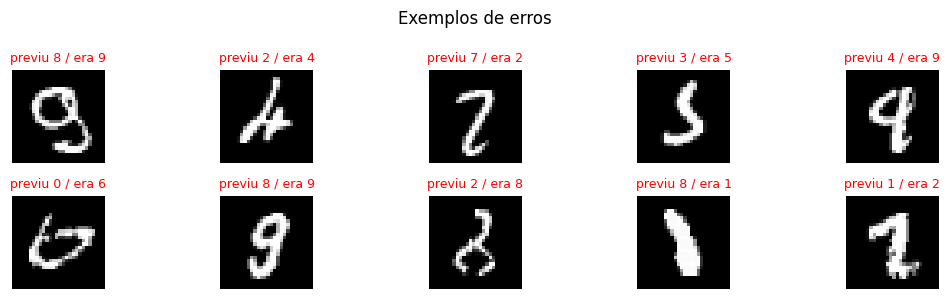

In [21]:
erros = np.where(preds != y_test)[0]
print(f'A rede errou {len(erros)} de {len(y_test)} imagens ({len(erros)/len(y_test)*100:.1f}%).')
plt.figure(figsize=(11,3))
for i, idx in enumerate(erros[:10]):
    plt.subplot(2,5,i+1); plt.imshow(x_test[idx], cmap='gray'); plt.axis('off')
    plt.title(f'previu {preds[idx]} / era {y_test[idx]}', color='red', fontsize=9)
plt.suptitle('Exemplos de erros'); plt.tight_layout(); plt.show()

In [22]:
model.save('modelo_mnist_mlp.keras')
print('Modelo treinado salvo em modelo_mnist_mlp.keras')

Modelo treinado salvo em modelo_mnist_mlp.keras


---
## Bônus — Rede Neural Convolucional (CNN)
A rede densa acima trata a imagem como uma lista de pixels soltos. Uma **CNN** olha a imagem em pequenas janelas, aprendendo a enxergar **bordas, traços e formas** — por isso é o padrão para imagens.

- **Conv2D**: filtros que deslizam pela imagem detectando padrões locais.
- **MaxPooling2D**: reduz o tamanho mantendo o que é importante.

A CNN precisa de um "canal" a mais na forma da imagem (28×28 → 28×28×1).

In [23]:
x_train_cnn = x_train[..., np.newaxis]   # (60000, 28, 28, 1)
x_test_cnn  = x_test[..., np.newaxis]

cnn = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10)
])
cnn.compile(optimizer='adam',
            loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
            metrics=['accuracy'])
cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
cnn.fit(x_train_cnn, y_train, epochs=5, batch_size=128, validation_split=0.1, verbose=2)
cnn_loss, cnn_acc = cnn.evaluate(x_test_cnn, y_test, verbose=0)
print(f'\n>>> Acuracia da CNN no TESTE: {cnn_acc*100:.2f}%')

Epoch 1/5
422/422 - 37s - 87ms/step - accuracy: 0.9001 - loss: 0.3309 - val_accuracy: 0.9825 - val_loss: 0.0653
Epoch 2/5
422/422 - 43s - 102ms/step - accuracy: 0.9684 - loss: 0.1069 - val_accuracy: 0.9857 - val_loss: 0.0478
Epoch 3/5
422/422 - 35s - 83ms/step - accuracy: 0.9768 - loss: 0.0775 - val_accuracy: 0.9863 - val_loss: 0.0421
Epoch 4/5
422/422 - 42s - 99ms/step - accuracy: 0.9809 - loss: 0.0628 - val_accuracy: 0.9880 - val_loss: 0.0383
Epoch 5/5
422/422 - 35s - 84ms/step - accuracy: 0.9844 - loss: 0.0525 - val_accuracy: 0.9885 - val_loss: 0.0376

>>> Acuracia da CNN no TESTE: 99.00%


Comparando as duas abordagens:

In [25]:
import pandas as pd
comp = pd.DataFrame({'Acuracia no teste (%)': [round(test_acc*100,2), round(cnn_acc*100,2)]},
                    index=['Rede densa (MLP)', 'Rede convolucional (CNN)'])
print(comp.to_string())

                          Acuracia no teste (%)
Rede densa (MLP)                          97.66
Rede convolucional (CNN)                  99.00


## Conclusão
Construímos, treinámos e avaliámos uma rede neural que reconhece dígitos manuscritos, seguindo os 6 passos do enunciado. A rede densa simples já acerta cerca de **98%** das imagens de teste, e a CNN chega a aproximadamente **99%**, errando quase só em dígitos realmente ambíguos.

A ideia central é a mesma do *"Hello World"* de um neurônio: a rede **não recebe regras** sobre como é cada dígito — ela aprende esses padrões sozinha, a partir dos exemplos, ajustando seus pesos até minimizar o erro.